In [1]:
#installing req library
!pip install scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 32.4 MB/s eta 0:00:00


In [2]:
#importing libraries
import pandas as pd
import numpy as np

from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

import matplotlib.pyplot as plt

In [3]:
#loading dataset
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

In [4]:
#viewing data
ratings.head()

,userId,movieId,rating,timestamp
0,1,2.0,3.5,1.112486e+09
1,1,29.0,3.5,1.112485e+09
2,1,32.0,3.5,1.112485e+09
3,1,47.0,3.5,1.112485e+09
4,1,50.0,3.5,1.112485e+09


In [5]:
#dataset shape
print(ratings.shape)
print(movies.shape)

(3586238, 4)
(27278, 3)


In [6]:
#keeping only req columns
ratings = ratings[['userId','movieId','rating']]

In [9]:
#reducing dataset for efficiency
ratings_sample = ratings.sample(
    n=100000,
    random_state=42
)

In [10]:
#preparing data for model
reader = Reader(rating_scale=(0.5,5))

data = Dataset.load_from_df(
    ratings_sample[['userId','movieId','rating']],
    reader
)

In [11]:
#split test train
trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

In [13]:
#creating model, collaborative filtering using SVD
model = SVD()

In [14]:
#training model
model.fit(trainset)

In [15]:
#making predictions
predictions = model.test(testset)

In [16]:
#evaluating model
rmse = accuracy.rmse(predictions)

RMSE: 0.9420


In [17]:
#predicting
prediction = model.predict(
    uid=1,
    iid=50
)

print(prediction.est)

4.3679009399587


In [18]:
#finding movie name
movies[movies['movieId']==50]

,movieId,title,genres
49,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


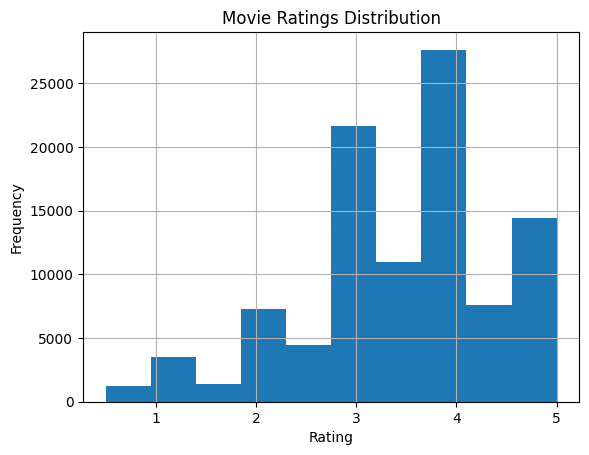

In [19]:
#visualiziation using histogram
ratings_sample['rating'].hist(
    bins=10
)

plt.title("Movie Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()